In [200]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [201]:
df=pd.read_csv("standard_scaler_dataset.csv")
df

,Age,Salary,Experience
0,56,32695,3
1,46,78190,7
2,32,35258,6
3,60,117538,8
4,25,69504,27
...,...,...,...
95,24,96842,23
96,26,91373,10
97,41,36776,3
98,18,122787,7


In [202]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         100 non-null    int64
 1   Salary      100 non-null    int64
 2   Experience  100 non-null    int64
dtypes: int64(3)
memory usage: 2.5 KB


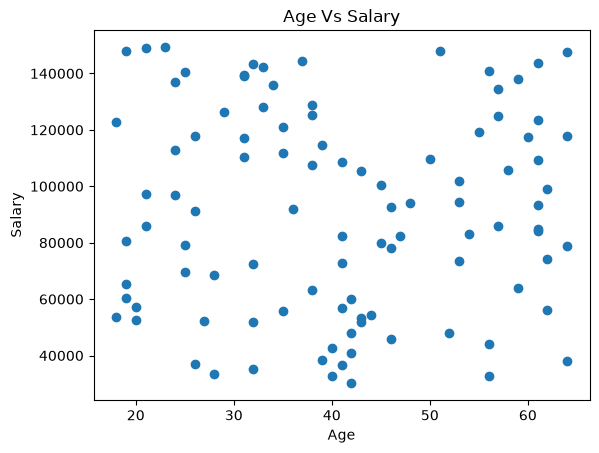

In [203]:
plt.scatter(df['Age'],df['Salary'])
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age Vs Salary')
plt.show()

### Defining x and y

In [204]:
x=df.drop(columns='Experience')
y=df['Experience']

### Train_test_split

In [205]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

### Model Creation for LinearRegression

In [206]:
model=LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.06,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Age','Salary']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.382
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


### Model Evaluation

In [207]:
# Train Data

ytrain_predicted=model.predict(xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))

0.026809335152035096
8.873527378865543
8.004486811628432


In [208]:
# Test Data

ytest_predicted=model.predict(xtest)

print(r2_score(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))

-0.010710682178010078
8.680350301478084
6.737975322651384


***Model performance is not good so we use Polynomial feature here***

### Polynomial Regression

In [209]:
model=PolynomialFeatures(degree=2)

updated_xtrain=model.fit_transform(xtrain)

updated_xtest=model.transform(xtest)


In [210]:
model=LinearRegression()

model.fit(updated_xtrain,ytrain)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0., 0., 0., 0., 0.,-0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[5.67e+10,1.36e+07,4.91e+04,3.74e+03,1.79e+01,0.00e+00]"


In [211]:
# #  Train Data

ytrain_predicted = model.predict(updated_xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))



0.04311026255104067
7.9329646142663055
8.798897830455926


In [212]:
# #  Test Data

ytest_predicted = model.predict(updated_xtest)

print(r2_score(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))



-0.013446507014856834
6.765852547799571
8.692090490667798


***After applying Polynomial Regression, if the model performance is still poor, we can try a scaling technique.***



In [213]:
xtrain.value_counts()

# Because here  numerial column values are in different range(To give same importance to both numerical column we use Scaling preprocess Technique.)

Age  Salary
64   117939    1
62   56105     1
39   114651    1
35   120982    1
61   123426    1
              ..
57   86044     1
27   52299     1
41   82251     1
62   74262     1
64   147478    1
Name: count, Length: 80, dtype: int64